# Data Parallelism — From Zero to Hero

> **Difficulty:** Beginner → Intermediate | **Time:** ~45 min

This notebook teaches **Data Parallelism (DP)** — the most fundamental technique
for training deep learning models across multiple GPUs.

**No prior distributed-training knowledge required.** We start from scratch.

## 1. Why Do We Need Multiple GPUs?

Imagine you're a teacher grading 1,000 exam papers alone — it takes forever.
But if 4 teachers each grade 250 papers and then **share their findings**,
the job finishes ~4× faster.

**Data Parallelism works exactly the same way:**
- Each GPU is a "teacher"
- The exam papers are your training data
- "Sharing findings" = synchronizing what each GPU learned (gradients)

Let's draw this idea first, then explain the details.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from mp_tutorial.distributed import check_gpu_env, simulate_allreduce
from mp_tutorial.viz import draw_comm_pattern
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference

### The Core Idea (One Picture)

Below is the **entire concept** of Data Parallelism in a single diagram.
Study this picture — everything else in the notebook expands on it.

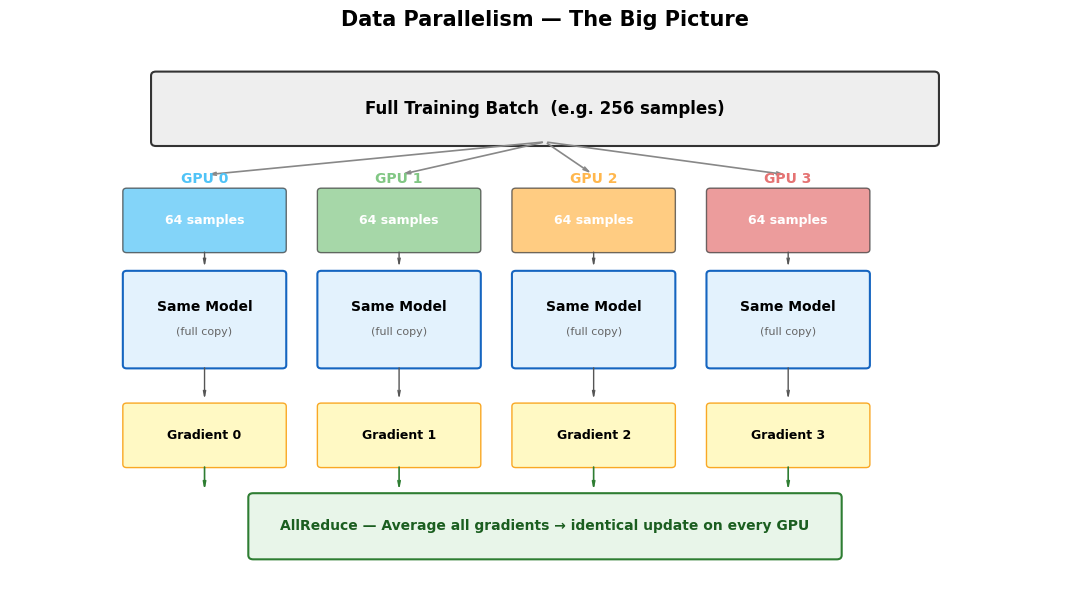

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6.5)
ax.axis("off")
ax.set_title("Data Parallelism — The Big Picture", fontsize=15, fontweight="bold", pad=12)

gpu_colors = ["#4FC3F7", "#81C784", "#FFB74D", "#E57373"]

# ── Full batch at top ──
ax.add_patch(patches.FancyBboxPatch((1.5, 5.3), 8, 0.8, boxstyle="round,pad=0.05",
    facecolor="#eeeeee", edgecolor="#333", lw=1.5))
ax.text(5.5, 5.7, "Full Training Batch  (e.g. 256 samples)", ha="center", va="center",
    fontsize=12, fontweight="bold")

# ── Split arrows ──
for i in range(4):
    x = 2.0 + i * 2.0
    ax.annotate("", xy=(x, 4.9), xytext=(5.5, 5.3),
        arrowprops=dict(arrowstyle="->,head_width=0.1", color="#888", lw=1.2))

# ── 4 GPU columns ──
for i in range(4):
    x = 1.2 + i * 2.0
    # micro-batch
    ax.add_patch(patches.FancyBboxPatch((x, 4.0), 1.6, 0.7, boxstyle="round,pad=0.04",
        facecolor=gpu_colors[i], edgecolor="#333", lw=1, alpha=0.7))
    ax.text(x + 0.8, 4.35, f"64 samples", ha="center", va="center", fontsize=9, color="white",
        fontweight="bold")

    # model copy
    ax.add_patch(patches.FancyBboxPatch((x, 2.6), 1.6, 1.1, boxstyle="round,pad=0.04",
        facecolor="#e3f2fd", edgecolor="#1565c0", lw=1.5))
    ax.text(x + 0.8, 3.3, "Same Model", ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(x + 0.8, 3.0, "(full copy)", ha="center", va="center", fontsize=8, color="#666")

    # arrow into model
    ax.annotate("", xy=(x + 0.8, 3.75), xytext=(x + 0.8, 4.0),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1))

    # gradient box
    ax.add_patch(patches.FancyBboxPatch((x, 1.4), 1.6, 0.7, boxstyle="round,pad=0.04",
        facecolor="#fff9c4", edgecolor="#f9a825", lw=1))
    ax.text(x + 0.8, 1.75, f"Gradient {i}", ha="center", va="center", fontsize=9, fontweight="bold")

    # arrow model -> gradient
    ax.annotate("", xy=(x + 0.8, 2.15), xytext=(x + 0.8, 2.6),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1))

    # GPU label
    ax.text(x + 0.8, 4.85, f"GPU {i}", ha="center", va="center", fontsize=10, fontweight="bold",
        color=gpu_colors[i])

# ── Sync arrows ──
ax.add_patch(patches.FancyBboxPatch((2.5, 0.3), 6, 0.7, boxstyle="round,pad=0.05",
    facecolor="#e8f5e9", edgecolor="#2e7d32", lw=1.5))
ax.text(5.5, 0.65, "AllReduce — Average all gradients → identical update on every GPU",
    ha="center", va="center", fontsize=10, fontweight="bold", color="#1b5e20")

for i in range(4):
    x = 2.0 + i * 2.0
    ax.annotate("", xy=(x, 1.05), xytext=(x, 1.4),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#2e7d32", lw=1.2))

plt.tight_layout()
plt.show()

### Key Terms (If This Is Your First Time)

Before we go deeper, let's make sure the vocabulary is clear:

In [3]:
info_box(
    "<b>Tensor</b> — A multi-dimensional array of numbers. "
    "A 1D tensor is a vector, 2D is a matrix. Model weights and data are all tensors.<br><br>"
    "<b>Forward Pass</b> — Feeding input data through the model to get a prediction.<br><br>"
    "<b>Loss</b> — A single number measuring how wrong the prediction is. Lower = better.<br><br>"
    "<b>Backward Pass (Backpropagation)</b> — Computing how much each weight contributed to the loss. "
    "The result is a <i>gradient</i> for each weight.<br><br>"
    "<b>Gradient</b> — A tensor the same shape as the weight, telling which direction to adjust "
    "each number to reduce the loss.<br><br>"
    "<b>Optimizer Step</b> — Actually updating the weights using the gradients "
    "(e.g., <code>weight -= learning_rate × gradient</code>).",
    title="Glossary — Core Deep Learning Terms"
)

## 2. Training on a Single GPU (Baseline)

Before parallelism, let's see how training works on **one GPU**.
This is the loop every GPU will run — data parallelism just runs it simultaneously.

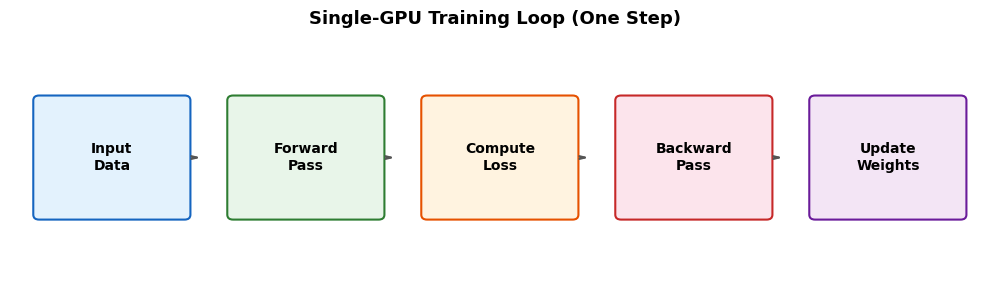

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")
ax.set_title("Single-GPU Training Loop (One Step)", fontsize=13, fontweight="bold", pad=8)

steps = [
    (0.3, "Input\nData", "#e3f2fd", "#1565c0"),
    (2.3, "Forward\nPass", "#e8f5e9", "#2e7d32"),
    (4.3, "Compute\nLoss", "#fff3e0", "#e65100"),
    (6.3, "Backward\nPass", "#fce4ec", "#c62828"),
    (8.3, "Update\nWeights", "#f3e5f5", "#6a1b9a"),
]
for i, (x, label, fc, ec) in enumerate(steps):
    ax.add_patch(patches.FancyBboxPatch((x, 0.8), 1.5, 1.4, boxstyle="round,pad=0.06",
        facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + 0.75, 1.5, label, ha="center", va="center", fontsize=10, fontweight="bold")
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + 1.7, 1.5), xytext=(x + 1.55, 1.5),
            arrowprops=dict(arrowstyle="->,head_width=0.1", color="#555", lw=1.5))

plt.tight_layout()
plt.show()

### See It With Real Numbers

Let's run one training step on a tiny model so you can see every number:

In [5]:
torch.manual_seed(42)

# A tiny model: just one linear layer (2 inputs → 3 outputs)
model = nn.Linear(2, 3, bias=False)
print("Model weights (before):")
print(model.weight.data)
print(f"Shape: {model.weight.shape}  (3 outputs × 2 inputs)\n")

# One tiny batch: 4 samples, each with 2 features
X = torch.tensor([[1.0, 0.0],
                   [0.0, 1.0],
                   [1.0, 1.0],
                   [0.5, 0.5]])
y_true = torch.tensor([[1.0, 0.0, 0.0],
                        [0.0, 1.0, 0.0],
                        [1.0, 1.0, 0.0],
                        [0.5, 0.5, 0.0]])

# Forward pass
y_pred = model(X)
print("Predictions (forward pass):")
print(y_pred.data.round(decimals=3))

# Compute loss
loss = ((y_pred - y_true) ** 2).mean()
print(f"\nLoss: {loss.item():.4f}")

# Backward pass
loss.backward()
print(f"\nGradients (same shape as weights):")
print(model.weight.grad.round(decimals=3))

# Update weights
lr = 0.1
with torch.no_grad():
    model.weight -= lr * model.weight.grad
print(f"\nModel weights (after update):")
print(model.weight.data.round(decimals=3))

Model weights (before):
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427]])
Shape: torch.Size([3, 2])  (3 outputs × 2 inputs)

Predictions (forward pass):
tensor([[ 0.5410, -0.1660, -0.1550],
        [ 0.5870,  0.6500,  0.1430],
        [ 1.1280,  0.4840, -0.0120],
        [ 0.5640,  0.2420, -0.0060]])

Loss: 0.0920

Gradients (same shape as weights):
tensor([[-0.0500,  0.1240],
        [-0.1350, -0.1660],
        [-0.0280,  0.0210]])

Model weights (after update):
tensor([[ 0.5460,  0.5740],
        [-0.1520,  0.6660],
        [-0.1520,  0.1410]])


## 3. Vanilla Data Parallelism

Now imagine we have **4 GPUs**. Instead of processing all 4 samples on one GPU,
we give each GPU just 1 sample. Each GPU:
1. Has its **own copy** of the model (same initial weights)
2. Processes its **own data shard**
3. Computes its **own gradient**

Then they **synchronize** so every GPU ends up with the same averaged gradient.

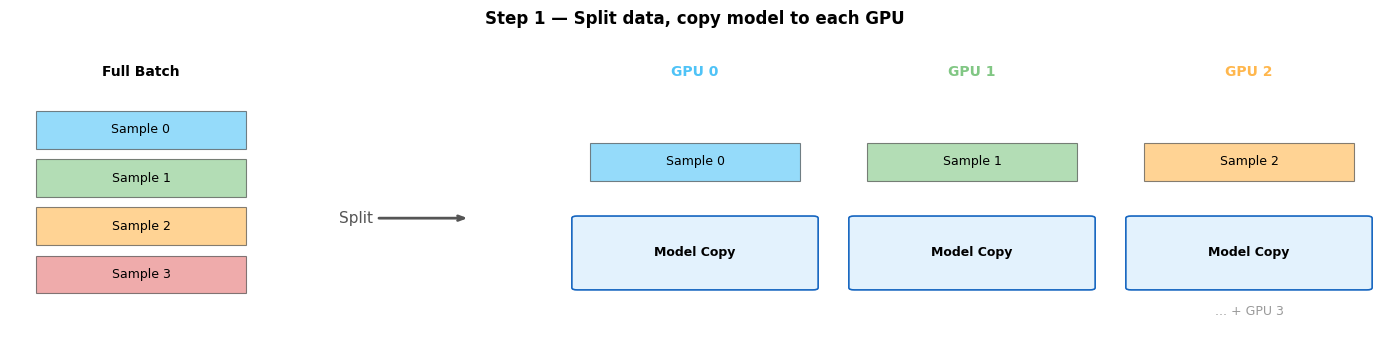

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
gpu_colors = ["#4FC3F7", "#81C784", "#FFB74D", "#E57373"]

# Full batch on the left
ax = axes[0]
ax.set_xlim(0, 2); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("Full Batch", fontsize=10, fontweight="bold")
for r in range(4):
    color = gpu_colors[r]
    ax.add_patch(patches.Rectangle((0.2, 3.8 - r * 0.9), 1.6, 0.7,
        facecolor=color, edgecolor="#333", lw=0.8, alpha=0.6))
    ax.text(1.0, 4.15 - r * 0.9, f"Sample {r}", ha="center", va="center", fontsize=9)

# Arrow
ax = axes[1]
ax.set_xlim(0, 1); ax.set_ylim(0, 5); ax.axis("off")
ax.annotate("Split", xy=(0.7, 2.5), xytext=(0.2, 2.5),
    arrowprops=dict(arrowstyle="->,head_width=0.15", color="#555", lw=2),
    fontsize=11, va="center", color="#555")

# Each GPU gets one sample
for g in range(3):
    ax = axes[g + 2]
    ax.set_xlim(0, 2); ax.set_ylim(0, 5); ax.axis("off")
    # Only show 3 GPUs due to space (GPU 0, 1, 2, ...)
    if g < 3:
        ax.set_title(f"GPU {g}", fontsize=10, fontweight="bold", color=gpu_colors[g])
        ax.add_patch(patches.Rectangle((0.2, 3.2), 1.6, 0.7,
            facecolor=gpu_colors[g], edgecolor="#333", lw=0.8, alpha=0.6))
        ax.text(1.0, 3.55, f"Sample {g}", ha="center", va="center", fontsize=9)
        # Model box
        ax.add_patch(patches.FancyBboxPatch((0.1, 1.2), 1.8, 1.3, boxstyle="round,pad=0.04",
            facecolor="#e3f2fd", edgecolor="#1565c0", lw=1.2))
        ax.text(1.0, 1.85, "Model Copy", ha="center", va="center", fontsize=9, fontweight="bold")
        if g == 2:
            ax.text(1.0, 0.7, "... + GPU 3", ha="center", fontsize=9, color="#999")

plt.suptitle("Step 1 — Split data, copy model to each GPU", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Simulate Vanilla DP With Real Tensors

Let's actually run this. We'll use `simulate_allreduce` to mimic GPU communication on CPU.

In [7]:
torch.manual_seed(42)
num_gpus = 4

# Same tiny model weights (replicated to each "GPU")
W_init = torch.randn(3, 2)
print("Initial weights (same on all GPUs):")
print(W_init.round(decimals=3))
print()

# Split our 4 samples — each GPU gets 1
all_X = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.5, 0.5]])
all_y = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [1.0, 1.0, 0.0], [0.5, 0.5, 0.0]])

local_grads = []
for i in range(num_gpus):
    W = W_init.clone().requires_grad_(True)
    x_i = all_X[i:i+1]   # 1 sample
    y_i = all_y[i:i+1]
    pred = x_i @ W.T
    loss = ((pred - y_i) ** 2).mean()
    loss.backward()
    local_grads.append(W.grad.clone())
    print(f"GPU {i}: sample={all_X[i].tolist()}, loss={loss.item():.4f}, grad_norm={W.grad.norm():.4f}")

print("\n--- Local gradients (each GPU sees different data, so gradients differ) ---")
for i, g in enumerate(local_grads):
    print(f"  GPU {i}: {g[0].tolist()}")

Initial weights (same on all GPUs):
tensor([[ 0.3370,  0.1290],
        [ 0.2340,  0.2300],
        [-1.1230, -0.1860]])

GPU 0: sample=[1.0, 0.0], loss=0.5853, grad_norm=0.8834
GPU 1: sample=[0.0, 1.0], loss=0.2146, grad_norm=0.5349
GPU 2: sample=[1.0, 1.0], loss=0.7620, grad_norm=1.4255
GPU 3: sample=[0.5, 0.5], loss=0.1905, grad_norm=0.3564

--- Local gradients (each GPU sees different data, so gradients differ) ---
  GPU 0: [-0.4422064423561096, 0.0]
  GPU 1: [0.0, 0.08587294071912766]
  GPU 2: [-0.35633349418640137, -0.35633349418640137]
  GPU 3: [-0.08908337354660034, -0.08908337354660034]


### Step 2 — Synchronize Gradients (AllReduce)

Now the magic step: **AllReduce** sums all gradients across GPUs, so every GPU
gets the same total. We then divide by N to get the average.

> **AllReduce** is a collective communication operation where every participant
> both *sends* its data and *receives* the combined result. It's like a group
> chat where everyone shares their answer and everyone sees the sum.

In [8]:
# AllReduce: every GPU gets the sum of all gradients
synced = simulate_allreduce(local_grads)
avg_grads = [g / num_gpus for g in synced]

print("After AllReduce + average:")
for i in range(num_gpus):
    print(f"  GPU {i}: {avg_grads[i][0].round(decimals=4).tolist()}")

print(f"\nAll identical? {all(torch.allclose(avg_grads[0], avg_grads[i]) for i in range(1, num_gpus))}")

# Compare with what a single GPU would compute on ALL data
W_full = W_init.clone().requires_grad_(True)
pred_full = all_X @ W_full.T
loss_full = ((pred_full - all_y) ** 2).mean()
loss_full.backward()
print(f"\nSingle-GPU gradient (all data):  {W_full.grad[0].round(decimals=4).tolist()}")
print(f"DP averaged gradient:             {avg_grads[0][0].round(decimals=4).tolist()}")
print(f"Match: {torch.allclose(avg_grads[0], W_full.grad)}")

After AllReduce + average:
  GPU 0: [-0.22190000116825104, -0.08990000188350677]
  GPU 1: [-0.22190000116825104, -0.08990000188350677]
  GPU 2: [-0.22190000116825104, -0.08990000188350677]
  GPU 3: [-0.22190000116825104, -0.08990000188350677]

All identical? True

Single-GPU gradient (all data):  [-0.22190000116825104, -0.08990000188350677]
DP averaged gradient:             [-0.22190000116825104, -0.08990000188350677]
Match: True


In [9]:
info_box(
    "The averaged gradient from 4 GPUs each processing ¼ of the data is "
    "<b>mathematically identical</b> to the gradient from 1 GPU processing all the data. "
    "Data Parallelism gives the exact same result — just faster!",
    title="Key Insight"
)

### Visualizing AllReduce

Here's how GPUs communicate during AllReduce. In a **ring** topology,
data flows around the ring so no single GPU is a bottleneck:

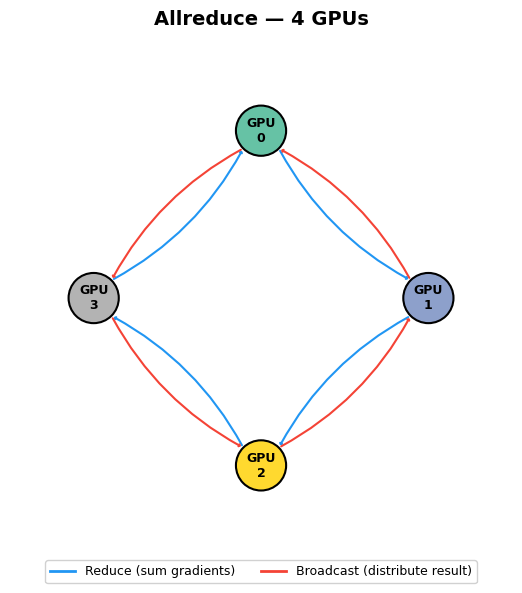

In [10]:
fig, ax = draw_comm_pattern("allreduce", num_gpus=4)
plt.show()

## 4. DistributedDataParallel (DDP) — The Smart Version

Vanilla DP works, but PyTorch's `DistributedDataParallel` makes it **faster** with two tricks:

### Trick 1: Gradient Bucketing

Instead of waiting for ALL gradients to be computed before synchronizing,
DDP groups gradients into **buckets** (~25 MB each) and starts synchronizing
each bucket as soon as it's ready.

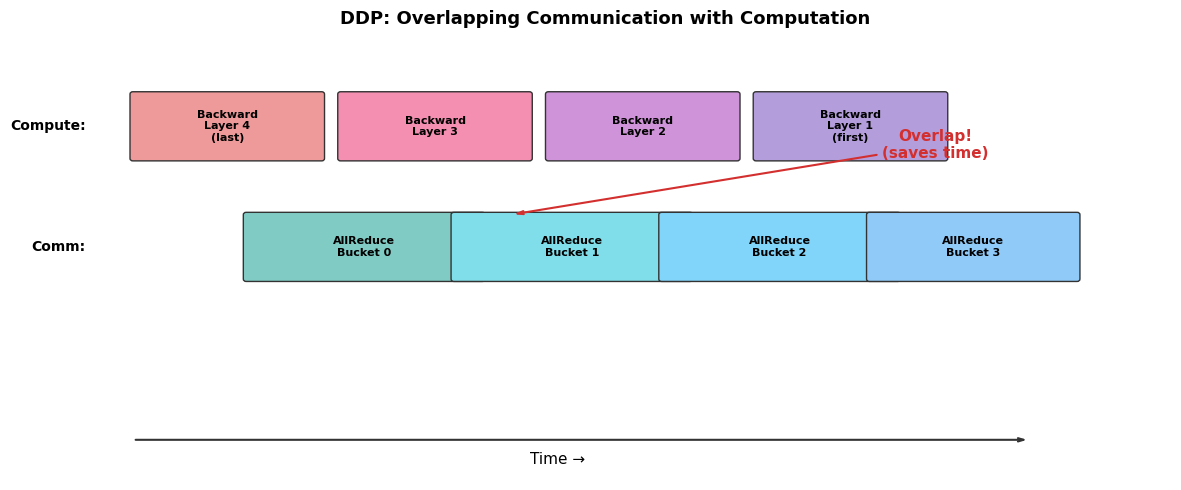

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("DDP: Overlapping Communication with Computation", fontsize=13, fontweight="bold", pad=10)

# Timeline for 1 GPU
y_comp = 4.0; y_comm = 2.5; y_opt = 1.2
bar_h = 0.8

# Backward computation blocks (layers computed right-to-left)
layers = ["Layer 4\n(last)", "Layer 3", "Layer 2", "Layer 1\n(first)"]
layer_colors = ["#ef9a9a", "#f48fb1", "#ce93d8", "#b39ddb"]
for i, (label, color) in enumerate(zip(layers, layer_colors)):
    x = 1 + i * 2.2
    ax.add_patch(patches.FancyBboxPatch((x, y_comp), 2.0, bar_h, boxstyle="round,pad=0.03",
        facecolor=color, edgecolor="#333", lw=1))
    ax.text(x + 1.0, y_comp + bar_h/2, f"Backward\n{label}", ha="center", va="center", fontsize=8, fontweight="bold")

# Communication blocks (start as soon as layer's bucket is ready)
comm_colors = ["#80cbc4", "#80deea", "#81d4fa", "#90caf9"]
for i in range(4):
    x = 2.2 + i * 2.2  # starts slightly after computation
    w = 2.5  # comm takes a bit longer but overlaps
    if x + w > 11:
        w = 11 - x
    ax.add_patch(patches.FancyBboxPatch((x, y_comm), w, bar_h, boxstyle="round,pad=0.03",
        facecolor=comm_colors[i], edgecolor="#333", lw=1))
    ax.text(x + w/2, y_comm + bar_h/2, f"AllReduce\nBucket {i}", ha="center", va="center",
        fontsize=8, fontweight="bold")

# Labels
ax.text(0.5, y_comp + bar_h/2, "Compute:", ha="right", va="center", fontsize=10, fontweight="bold")
ax.text(0.5, y_comm + bar_h/2, "Comm:", ha="right", va="center", fontsize=10, fontweight="bold")

# Overlap annotation
ax.annotate("Overlap!\n(saves time)", xy=(5, 3.3), xytext=(9.5, 4.0),
    arrowprops=dict(arrowstyle="->,head_width=0.1", color="#d32f2f", lw=1.5),
    fontsize=11, fontweight="bold", color="#d32f2f", ha="center")

# Time arrow
ax.annotate("", xy=(10.5, 0.5), xytext=(1, 0.5),
    arrowprops=dict(arrowstyle="->,head_width=0.12", color="#333", lw=1.5))
ax.text(5.5, 0.2, "Time →", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
info_box(
    "<b>Gradient Bucketing</b> — DDP doesn't sync one gradient at a time (too many small messages) "
    "or all at once (too much waiting). Instead, it groups gradients into ~25 MB buckets and "
    "syncs each bucket as soon as all its gradients are ready. This <i>overlaps</i> communication "
    "with the backward pass, hiding most of the sync cost.",
    title="Why Bucketing Matters"
)

## 5. The Memory Problem — Why We Need ZeRO

Standard DP copies **everything** to every GPU. Let's see how much memory that wastes:

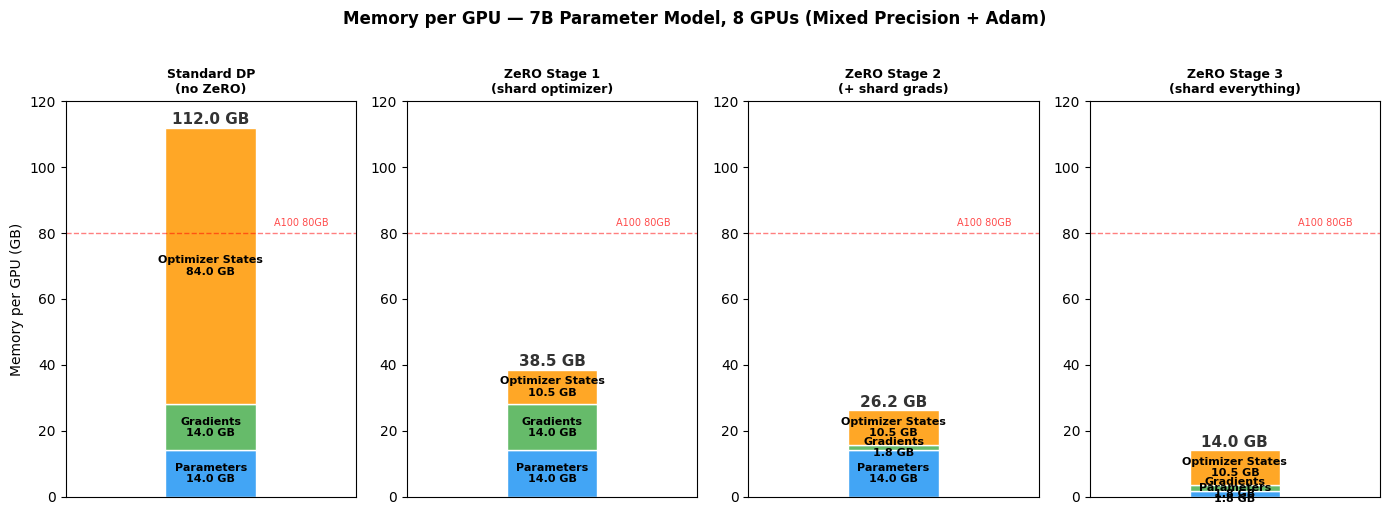

ZeRO Stage,Params (GB),Grads (GB),Optimizer (GB),Total (GB),Fits A100 80GB?
None (DDP),14.0,14.0,84.0,112.0,NO
Stage 1,14.0,14.0,10.5,38.5,Yes
Stage 2,14.0,1.8,10.5,26.2,Yes
Stage 3,1.8,1.8,10.5,14.0,Yes


In [13]:
# Memory breakdown for a model with P parameters (mixed precision + Adam)
def memory_breakdown(num_params_B, num_gpus, zero_stage=0):
    """Calculate per-GPU memory in GB for mixed-precision training with Adam."""
    P = num_params_B * 1e9
    bytes_per_param = 2  # fp16 parameters

    if zero_stage == 0:  # Standard DP
        params_gb = P * 2 / 1e9           # fp16 params
        grads_gb = P * 2 / 1e9            # fp16 gradients
        opt_gb = P * (4 + 4 + 4) / 1e9    # fp32 master + momentum + variance
    elif zero_stage == 1:  # Partition optimizer
        params_gb = P * 2 / 1e9
        grads_gb = P * 2 / 1e9
        opt_gb = P * 12 / 1e9 / num_gpus
    elif zero_stage == 2:  # + partition gradients
        params_gb = P * 2 / 1e9
        grads_gb = P * 2 / 1e9 / num_gpus
        opt_gb = P * 12 / 1e9 / num_gpus
    else:  # Stage 3: partition everything
        params_gb = P * 2 / 1e9 / num_gpus
        grads_gb = P * 2 / 1e9 / num_gpus
        opt_gb = P * 12 / 1e9 / num_gpus

    return params_gb, grads_gb, opt_gb

# Compare for a 7B model on 8 GPUs
model_size = 7  # billion params
n_gpus = 8

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
stages = ["Standard DP\n(no ZeRO)", "ZeRO Stage 1\n(shard optimizer)",
          "ZeRO Stage 2\n(+ shard grads)", "ZeRO Stage 3\n(shard everything)"]
bar_colors = ["#42a5f5", "#66bb6a", "#ffa726"]
labels = ["Parameters", "Gradients", "Optimizer States"]

for idx, (ax, title) in enumerate(zip(axes, stages)):
    p, g, o = memory_breakdown(model_size, n_gpus, zero_stage=idx)
    heights = [p, g, o]
    bottom = 0
    for h, c, lab in zip(heights, bar_colors, labels):
        bar = ax.bar(0, h, bottom=bottom, color=c, edgecolor="white", width=0.5)
        if h > 1.5:
            ax.text(0, bottom + h/2, f"{lab}\n{h:.1f} GB", ha="center", va="center",
                fontsize=8, fontweight="bold")
        elif h > 0.3:
            ax.text(0, bottom + h/2, f"{h:.1f}", ha="center", va="center", fontsize=7)
        bottom += h
    total = sum(heights)
    ax.text(0, bottom + 1, f"{total:.1f} GB", ha="center", fontsize=11, fontweight="bold", color="#333")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(0, 120)
    ax.set_xticks([])
    if idx == 0:
        ax.set_ylabel("Memory per GPU (GB)", fontsize=10)

# Add A100 80GB line
for ax in axes:
    ax.axhline(y=80, color="red", linestyle="--", alpha=0.5, lw=1)
    ax.text(0.35, 82, "A100 80GB", fontsize=7, color="red", alpha=0.7)

fig.suptitle(f"Memory per GPU — {model_size}B Parameter Model, {n_gpus} GPUs (Mixed Precision + Adam)",
    fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Table
rows = []
for stage in range(4):
    p, g, o = memory_breakdown(model_size, n_gpus, zero_stage=stage)
    total = p + g + o
    fits = "Yes" if total < 80 else "NO"
    rows.append([f"Stage {stage}" if stage > 0 else "None (DDP)", f"{p:.1f}", f"{g:.1f}", f"{o:.1f}", f"{total:.1f}", fits])
comparison_table(
    ["ZeRO Stage", "Params (GB)", "Grads (GB)", "Optimizer (GB)", "Total (GB)", "Fits A100 80GB?"],
    rows,
    title=f"Memory Breakdown: {model_size}B Model on {n_gpus} GPUs"
)

### How ZeRO Partitions Memory

The key idea: **why store the same thing on every GPU?**
Instead, each GPU owns a *shard* (1/N-th slice) of the data it doesn't need all the time.

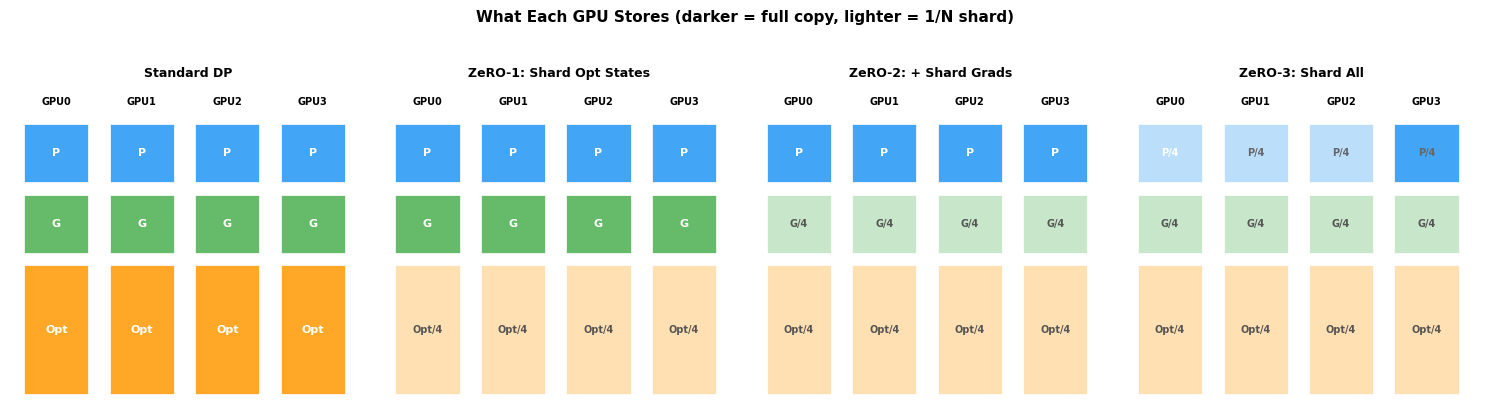

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ["Standard DP", "ZeRO-1: Shard Opt States", "ZeRO-2: + Shard Grads", "ZeRO-3: Shard All"]

for ax_idx, (ax, title) in enumerate(zip(axes, titles)):
    ax.set_xlim(0, 5); ax.set_ylim(0, 5); ax.axis("off")
    ax.set_title(title, fontsize=9, fontweight="bold")

    for gpu in range(4):
        x = 0.2 + gpu * 1.2
        # GPU label
        ax.text(x + 0.45, 4.7, f"GPU{gpu}", ha="center", fontsize=7, fontweight="bold")

        # Parameters (blue)
        if ax_idx < 3:  # stages 0,1,2 keep full params
            ax.add_patch(patches.Rectangle((x, 3.5), 0.9, 0.9,
                facecolor="#42a5f5", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 3.95, "P", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:  # stage 3
            ax.add_patch(patches.Rectangle((x, 3.5), 0.9, 0.9,
                facecolor="#bbdefb" if gpu != ax_idx % 4 else "#42a5f5", edgecolor="white", lw=0.5))
            t = "P" if gpu == 0 else ""
            ax.text(x + 0.45, 3.95, f"P/{4}" if True else t, ha="center", va="center", fontsize=7,
                color="white" if gpu == 0 else "#666", fontweight="bold")

        # Gradients (green)
        if ax_idx < 2:  # stages 0,1 keep full grads
            ax.add_patch(patches.Rectangle((x, 2.4), 0.9, 0.9,
                facecolor="#66bb6a", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 2.85, "G", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:
            ax.add_patch(patches.Rectangle((x, 2.4), 0.9, 0.9,
                facecolor="#c8e6c9" if True else "#66bb6a", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 2.85, f"G/{4}", ha="center", va="center", fontsize=7, color="#555", fontweight="bold")

        # Optimizer states (orange) — always the biggest
        if ax_idx == 0:  # full optimizer everywhere
            ax.add_patch(patches.Rectangle((x, 0.2), 0.9, 2.0,
                facecolor="#ffa726", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 1.2, "Opt", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:  # sharded
            ax.add_patch(patches.Rectangle((x, 0.2), 0.9, 2.0,
                facecolor="#ffe0b2", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 1.2, f"Opt/{4}", ha="center", va="center", fontsize=7, color="#555", fontweight="bold")

fig.suptitle("What Each GPU Stores (darker = full copy, lighter = 1/N shard)", fontsize=11, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 6. FSDP — ZeRO Stage 3 in PyTorch

**Fully Sharded Data Parallel (FSDP)** is PyTorch's built-in implementation of ZeRO Stage 3.

The lifecycle of parameters in FSDP:

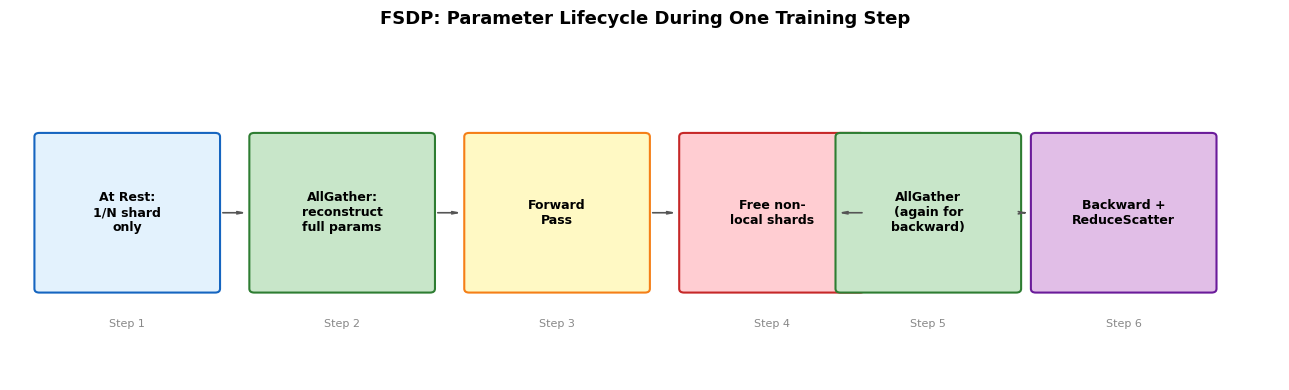

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.5)
ax.axis("off")
ax.set_title("FSDP: Parameter Lifecycle During One Training Step", fontsize=13, fontweight="bold", pad=10)

steps = [
    (0.3,  "At Rest:\n1/N shard\nonly", "#e3f2fd", "#1565c0"),
    (2.5,  "AllGather:\nreconstruct\nfull params", "#c8e6c9", "#2e7d32"),
    (4.7,  "Forward\nPass", "#fff9c4", "#f57f17"),
    (6.9,  "Free non-\nlocal shards", "#ffcdd2", "#c62828"),
    (8.5,  "AllGather\n(again for\nbackward)", "#c8e6c9", "#2e7d32"),
    (10.5, "Backward +\nReduceScatter", "#e1bee7", "#6a1b9a"),
]

for i, (x, label, fc, ec) in enumerate(steps):
    w = 1.8
    ax.add_patch(patches.FancyBboxPatch((x, 1.2), w, 2.0, boxstyle="round,pad=0.05",
        facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + w/2, 2.2, label, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(x + w/2, 0.7, f"Step {i+1}", ha="center", fontsize=8, color="#888")
    if i < len(steps) - 1:
        nx = steps[i+1][0]
        ax.annotate("", xy=(nx - 0.05, 2.2), xytext=(x + w + 0.05, 2.2),
            arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1.2))

plt.tight_layout()
plt.show()

In [16]:
info_box(
    "<b>AllGather</b> — Each GPU sends its shard to all other GPUs, so everyone reconstructs "
    "the full tensor. Like everyone sharing their puzzle piece so all can see the full picture.<br><br>"
    "<b>ReduceScatter</b> — The opposite: sum up everyone's data, then give each GPU only its "
    "1/N-th chunk of the result. Combines reduction and distribution in one step.",
    title="New Terms: AllGather & ReduceScatter"
)

### Communication Cost: DDP vs FSDP

FSDP trades **more communication** for **much less memory**:

In [17]:
comparison_table(
    ["", "DDP", "FSDP (ZeRO-3)"],
    [
        ["Memory per GPU", "Full model + grads + optimizer", "1/N of everything"],
        ["Communication / step", "2 × model_size<br>(1 AllReduce = ReduceScatter + AllGather)",
         "3 × model_size<br>(AllGather×2 + ReduceScatter)"],
        ["Comm overhead vs DDP", "1×", "1.5×"],
        ["When to use", "Model fits in 1 GPU memory", "Model too large for 1 GPU"],
    ],
    title="DDP vs FSDP Trade-off"
)

,DDP,FSDP (ZeRO-3)
Memory per GPU,Full model + grads + optimizer,1/N of everything
Communication / step,2 × model_size(1 AllReduce = ReduceScatter + AllGather),3 × model_size(AllGather×2 + ReduceScatter)
Comm overhead vs DDP,1×,1.5×
When to use,Model fits in 1 GPU memory,Model too large for 1 GPU


## 7. Data Parallelism in Large Language Models

In practice, DP is the **backbone** of ALL large model training.
Here's how the industry uses it:

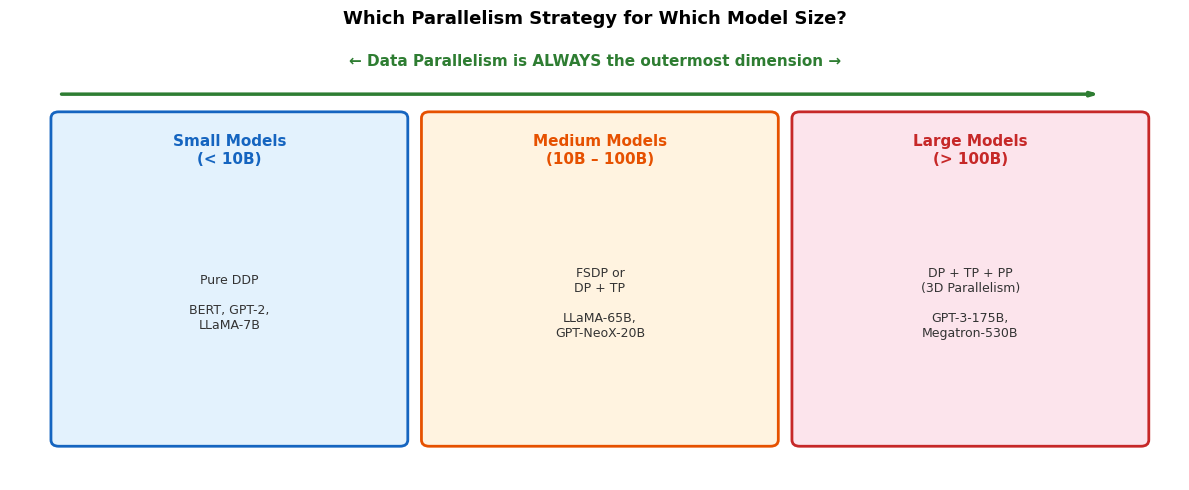

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("Which Parallelism Strategy for Which Model Size?", fontsize=13, fontweight="bold", pad=10)

# Regions
regions = [
    (0.5, 0.5, 3.5, 4.0, "#e3f2fd", "Small Models\n(< 10B)",
     "Pure DDP\n\nBERT, GPT-2,\nLLaMA-7B", "#1565c0"),
    (4.3, 0.5, 3.5, 4.0, "#fff3e0", "Medium Models\n(10B – 100B)",
     "FSDP or\nDP + TP\n\nLLaMA-65B,\nGPT-NeoX-20B", "#e65100"),
    (8.1, 0.5, 3.5, 4.0, "#fce4ec", "Large Models\n(> 100B)",
     "DP + TP + PP\n(3D Parallelism)\n\nGPT-3-175B,\nMegatron-530B", "#c62828"),
]
for x, y, w, h, fc, title, desc, ec in regions:
    ax.add_patch(patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
        facecolor=fc, edgecolor=ec, lw=2))
    ax.text(x + w/2, y + h - 0.4, title, ha="center", va="center", fontsize=11, fontweight="bold", color=ec)
    ax.text(x + w/2, y + h/2 - 0.3, desc, ha="center", va="center", fontsize=9, color="#333")

# Arrow showing that DP is always present
ax.annotate("", xy=(11.2, 4.8), xytext=(0.5, 4.8),
    arrowprops=dict(arrowstyle="->,head_width=0.12", color="#2e7d32", lw=2.5))
ax.text(6, 5.15, "← Data Parallelism is ALWAYS the outermost dimension →",
    ha="center", fontsize=11, fontweight="bold", color="#2e7d32")

plt.tight_layout()
plt.show()

In [19]:
info_box(
    "In multi-dimensional parallelism (e.g. TP × PP × DP), Data Parallelism is always the "
    "<b>outermost</b> layer because:<br>"
    "1. It only communicates once per training step (gradient sync)<br>"
    "2. It scales linearly — double GPUs ≈ double throughput<br>"
    "3. No pipeline bubbles or activation memory overhead",
    title="Why DP is Always the Outer Dimension"
)

### Scaling Efficiency

As we add GPUs, communication overhead grows. Let's visualize:

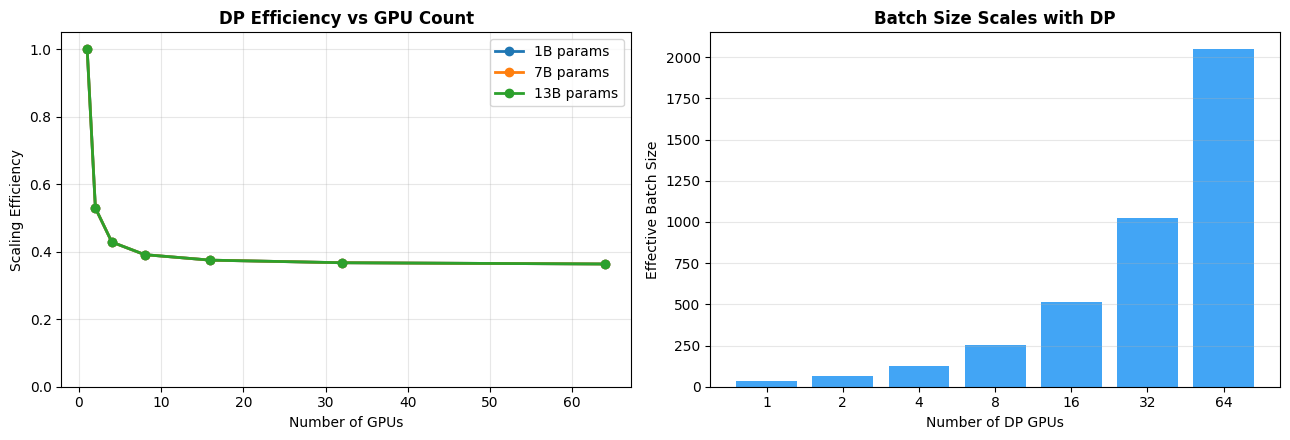

In [20]:
model_sizes_B = [1, 7, 13]
gpu_counts = [1, 2, 4, 8, 16, 32, 64]
bandwidth_gbps = 300  # inter-node bandwidth (GB/s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for model_B in model_sizes_B:
    compute_ms = model_B * 15  # rough: ~15ms per B params
    effs = []
    for n in gpu_counts:
        if n == 1:
            effs.append(1.0)
            continue
        data_gb = model_B * 1e9 * 4 / 1e9  # fp32 gradients
        comm_ms = 2 * (n-1)/n * data_gb / bandwidth_gbps * 1000
        eff = compute_ms / (compute_ms + comm_ms)
        effs.append(eff)
    ax1.plot(gpu_counts, effs, "o-", lw=2, label=f"{model_B}B params")

ax1.set_xlabel("Number of GPUs", fontsize=10)
ax1.set_ylabel("Scaling Efficiency", fontsize=10)
ax1.set_title("DP Efficiency vs GPU Count", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Batch size scaling
dp_sizes = [1, 2, 4, 8, 16, 32, 64]
local_batch = 32
ax2.bar(range(len(dp_sizes)), [local_batch * n for n in dp_sizes], color="#42a5f5")
ax2.set_xticks(range(len(dp_sizes)))
ax2.set_xticklabels(dp_sizes)
ax2.set_xlabel("Number of DP GPUs", fontsize=10)
ax2.set_ylabel("Effective Batch Size", fontsize=10)
ax2.set_title("Batch Size Scales with DP", fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 8. Hands-On: Real DDP Training Script

Below is a **complete, runnable** DDP training script. Save it and run on a multi-GPU machine:

```bash
# On a multi-GPU machine:
torchrun --nproc_per_node=4 ddp_train.py
```

In [21]:
gpu_required_banner()

In [22]:
# [GPU-REQUIRED]
# Complete DDP training script — save as ddp_train.py

DDP_SCRIPT = '''\
import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, TensorDataset, DistributedSampler

def main():
    # 1. Initialize distributed — NCCL backend for GPUs
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()          # This GPU's ID (0, 1, 2, ...)
    world_size = dist.get_world_size()  # Total number of GPUs
    device = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(device)

    # 2. Create model and move to this GPU
    model = nn.Sequential(
        nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 10)
    ).to(device)

    # 3. Wrap with DDP — this handles gradient sync automatically
    model = DDP(model, device_ids=[rank])

    # 4. Dataset + DistributedSampler (splits data across GPUs)
    X = torch.randn(1000, 128)
    y = torch.randint(0, 10, (1000,))
    sampler = DistributedSampler(TensorDataset(X, y), num_replicas=world_size, rank=rank)
    loader = DataLoader(TensorDataset(X, y), batch_size=32, sampler=sampler)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    # 5. Train
    for epoch in range(5):
        sampler.set_epoch(epoch)   # different shuffle each epoch
        total_loss = 0.0
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(batch_X), batch_y)
            loss.backward()        # DDP syncs gradients here automatically!
            optimizer.step()
            total_loss += loss.item()
        if rank == 0:
            print(f"Epoch {epoch+1}: loss = {total_loss/len(loader):.4f}")

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
'''

print(DDP_SCRIPT)
print("# Run with: torchrun --nproc_per_node=4 ddp_train.py")

import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, TensorDataset, DistributedSampler

def main():
    # 1. Initialize distributed — NCCL backend for GPUs
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()          # This GPU's ID (0, 1, 2, ...)
    world_size = dist.get_world_size()  # Total number of GPUs
    device = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(device)

    # 2. Create model and move to this GPU
    model = nn.Sequential(
        nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 10)
    ).to(device)

    # 3. Wrap with DDP — this handles gradient sync automatically
    model = DDP(model, device_ids=[rank])

    # 4. Dataset + DistributedSampler (splits data across GPUs)
    X = torch.randn(1000, 128)
    y = torch.randint(0, 10, (1000,))
    sampler = DistributedSampler(TensorDataset(X, y), num_replicas=world_size

## 9. Megatron-LM Reference

In Megatron's 3D parallelism framework, DP is combined with TP and PP.
Key implementation details:

In [22]:
code_reference(
    code="""# Megatron-LM organizes GPUs into process groups.
# Data-parallel group = GPUs with same TP rank + same PP stage
# but processing DIFFERENT data shards.
#
# Example: 16 GPUs, TP=4, PP=1, DP=4
# TP groups: [0,1,2,3], [4,5,6,7], [8,9,10,11], [12,13,14,15]
# DP groups: [0,4,8,12], [1,5,9,13], [2,6,10,14], [3,7,11,15]
#
# Each DP group runs AllReduce independently.
# megatron/core/parallel_state.py
def initialize_model_parallel(
    tensor_model_parallel_size,
    pipeline_model_parallel_size, ...
):
    # Builds DP groups from remaining GPUs after TP/PP assignment
    ...""",
    source="Megatron-LM",
    filepath="megatron/core/parallel_state.py"
)

In [23]:
code_reference(
    code="""# Megatron uses its own DDP wrapper (not PyTorch's)
# because the model is already split by TP/PP.
#
# megatron/core/distributed/distributed_data_parallel.py
class DistributedDataParallel(MegatronModule):
    '''Gradient AllReduce within data-parallel process groups.

    Key differences from torch DDP:
    - Only AllReduces within the DP group (not all GPUs)
    - Works with models already split by TP and PP
    - Supports gradient accumulation across micro-batches
    '''""",
    source="Megatron-LM",
    filepath="megatron/core/distributed/distributed_data_parallel.py"
)

## 10. Summary

What we covered in this notebook:

In [24]:
comparison_table(
    ["Technique", "Key Idea", "Memory", "Communication", "When to Use"],
    [
        ["Vanilla DP", "Replicate model, split data, average gradients",
         "Full copy on each GPU", "Naive gather → bottleneck", "Understanding only (not used in practice)"],
        ["DDP", "AllReduce + gradient bucketing + overlap",
         "Full copy on each GPU", "2× model size (efficient)", "Model fits in 1 GPU"],
        ["ZeRO-1", "Shard optimizer states across GPUs",
         "~4× less optimizer memory", "Same as DDP", "Optimizer is the bottleneck"],
        ["ZeRO-2", "ZeRO-1 + shard gradients",
         "Even less", "Same as DDP", "Need more memory savings"],
        ["ZeRO-3 / FSDP", "Shard everything (params + grads + opt)",
         "1/N of everything", "3× model size (1.5× DDP)", "Model doesn't fit in 1 GPU"],
    ],
    title="Data Parallelism Family — Comparison"
)

Technique,Key Idea,Memory,Communication,When to Use
Vanilla DP,"Replicate model, split data, average gradients",Full copy on each GPU,Naive gather → bottleneck,Understanding only (not used in practice)
DDP,AllReduce + gradient bucketing + overlap,Full copy on each GPU,2× model size (efficient),Model fits in 1 GPU
ZeRO-1,Shard optimizer states across GPUs,~4× less optimizer memory,Same as DDP,Optimizer is the bottleneck
ZeRO-2,ZeRO-1 + shard gradients,Even less,Same as DDP,Need more memory savings
ZeRO-3 / FSDP,Shard everything (params + grads + opt),1/N of everything,3× model size (1.5× DDP),Model doesn't fit in 1 GPU


### Key Formulas

| Formula | Meaning |
|---------|---------|
| $g_{\text{avg}} = \frac{1}{N} \sum_{i=1}^{N} g_i$ | Gradient averaging across N GPUs |
| $B_{\text{effective}} = b_{\text{local}} \times N_{\text{DP}} \times \text{grad\_accum}$ | Effective batch size |
| DDP comm: $2 \times |\theta|$ | AllReduce = ReduceScatter + AllGather |
| FSDP comm: $3 \times |\theta|$ | 2× AllGather + 1× ReduceScatter |

### Next Notebook

**[02 — Tensor Parallelism](02-tensor-parallelism.ipynb)**: Splitting individual *layers* across GPUs (complementary to DP).

### Further Reading

- [ZeRO: Memory Optimizations Toward Training Trillion Parameter Models](https://arxiv.org/abs/1910.02054)
- [PyTorch DDP Tutorial](https://pytorch.org/tutorials/beginner/dist_overview.html)
- [PyTorch FSDP Tutorial](https://pytorch.org/tutorials/intermediate/FSDP_tutorial.html)
- [Efficient Large-Scale Language Model Training on GPU Clusters](https://arxiv.org/abs/2104.04473)